# DEC-ACSA — Dynamic Elite Cooperative Artificial Circulatory System Algorithm


Artificial Circulatory System Algorithm (ACSA): https://doi.org/10.32604/cmes.2024.055860

Levy Flight-based Artificial Circulatory System Algorithm (LF-ACSA): https://doi.org/10.1016/j.aeue.2025.156101

Dynamic Elite Cooperative Artificial Circulatory System Algorithm (DEC-ACSA): https://doi.org/10.3390/engproc2026152004

# Imports

In [38]:
from pathlib import Path
from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt
import math

# BASE

In [39]:
class OptimizerBase:
    """Shared minimization infrastructure for both algorithms."""

    def __init__(self, obj_func, lb, ub, pop_size, max_fes, seed):
        self.obj_func = obj_func
        self.lb = np.atleast_1d(np.asarray(lb, dtype=float))
        self.ub = np.atleast_1d(np.asarray(ub, dtype=float))
        if self.lb.shape != self.ub.shape or self.lb.ndim != 1:
            raise ValueError("lb and ub must be matching one-dimensional arrays.")
        if not np.all(np.isfinite(self.lb)) or not np.all(np.isfinite(self.ub)):
            raise ValueError("Bounds must be finite.")
        if np.any(self.lb >= self.ub):
            raise ValueError("Each lower bound must be below its upper bound.")
        if int(pop_size) != pop_size or pop_size < 4:
            raise ValueError("pop_size must be an integer >= 4.")
        if int(max_fes) != max_fes or max_fes < pop_size:
            raise ValueError("max_fes must be an integer >= pop_size.")
        self.dim = self.lb.size
        self.pop_size = int(pop_size)
        self.max_fes = int(max_fes)
        self.rng = np.random.default_rng(seed)
        self.obj = SimpleNamespace(nfe=0)

    def evaluate(self, x):
        value = float(self.obj_func(x))
        self.obj.nfe += 1
        if not np.isfinite(value):
            raise ValueError("The objective must return a finite scalar.")
        return value

    def initialize(self):
        self.obj.nfe = 0
        self.fe_history = []
        self.conv_history = []
        if hasattr(self, "group_history"):
            self.group_history = []
        self.pop = self.rng.uniform(self.lb, self.ub,
                                    size=(self.pop_size, self.dim))
        self.fit = np.array([self.evaluate(x) for x in self.pop])
        self.refresh_best()
        self.record()

    def refresh_best(self):
        best_idx = int(np.argmin(self.fit))
        self.best_solution = self.pop[best_idx].copy()
        self.best_fitness = float(self.fit[best_idx])

    def record(self):
        if not self.fe_history or self.fe_history[-1] != self.obj.nfe:
            self.fe_history.append(self.obj.nfe)
            self.conv_history.append(self.best_fitness)

    def try_replace(self, idx, candidate):
        if self.obj.nfe >= self.max_fes:
            return
        candidate = np.clip(candidate, self.lb, self.ub)
        value = self.evaluate(candidate)
        if value < self.fit[idx]:
            self.pop[idx] = candidate
            self.fit[idx] = value
            if value < self.best_fitness:
                self.best_solution = candidate.copy()
                self.best_fitness = value
        # Record every candidate evaluation: a common horizontal axis.
        self.record()

# Original ACSA

In [40]:
class ACSA(OptimizerBase):
    def __init__(self, obj_func, lb, ub, pop_size=100, max_fes=50100, NH_rate=0.2, S=0.1, seed=None):
        super().__init__(obj_func, lb, ub, pop_size, max_fes, seed)
        self.NH_rate, self.S = float(NH_rate), float(S)
        self.Ea_neural, self.Es_neural = 1.8, 0.002
        self.Ea_hormonal, self.Es_hormonal = 0.66, 0.33

    def stimulation(self, x, kind):
        Ea, Es = (self.Ea_neural, self.Es_neural) if kind == 'neural' else (self.Ea_hormonal, self.Es_hormonal)
        return (self.ub-self.lb)*self.S/(1.0 + np.exp(Ea*(-x+Es)))

    def grouping(self):
        order = np.argsort(self.fit)[::-1]  # worst -> best
        nN = max(1, int(round(len(order)*self.NH_rate)))
        nN = min(nN, len(order)-1)
        return order[:nN], order[nN:]

    def optimize(self):
        self.initialize()
        while self.obj.nfe < self.max_fes:
            neural, hormonal = self.grouping()
            for idx in neural:
                if self.obj.nfe >= self.max_fes: break
                sf = self.stimulation(self.pop[idx], 'neural')
                candidate = self.rng.random(self.dim) * sf
                self.try_replace(int(idx), candidate)
            for idx in hormonal:
                if self.obj.nfe >= self.max_fes: break
                mean = np.mean(self.pop, axis=0)
                if self.rng.random() < 0.5:
                    sf = self.stimulation(self.pop[idx], 'hormonal')
                    candidate = mean + self.rng.random(self.dim)*sf
                else:
                    candidate = self.best_solution + self.rng.random(self.dim)*(mean-self.pop[idx])
                self.try_replace(int(idx), candidate)
            self.refresh_best(); self.record()
        return self.best_solution.copy(), self.best_fitness, np.asarray(self.fe_history), np.asarray(self.conv_history), self.obj.nfe

# LF-ACSA

In [41]:
class ACSA_Levy(ACSA):
    """LF-ACSA using the shared OptimizerBase inherited through ACSA.

    The supplied neural candidate equation is preserved:
        candidate = levy_scale * levy_flight(dim) * stimulation(x)
    max_fes includes initialization; dimension is inferred from the bounds.
    """

    def __init__(self, obj_func, lb, ub, pop_size=20, max_fes=1020,
                 NH_rate=0.1, S=0.1, levy_beta=1.5, levy_scale=0.01,
                 seed=None):
        super().__init__(obj_func, lb, ub, pop_size=pop_size,
                         max_fes=max_fes, NH_rate=NH_rate, S=S, seed=seed)
        if not np.isfinite(levy_beta) or not 0 < levy_beta < 2:
            raise ValueError("levy_beta must lie strictly between 0 and 2.")
        if not np.isfinite(levy_scale) or levy_scale <= 0:
            raise ValueError("levy_scale must be positive and finite.")
        if not np.isfinite(NH_rate) or not 0 < NH_rate < 1:
            raise ValueError("NH_rate must lie strictly between 0 and 1.")
        self.levy_beta = float(levy_beta)
        self.levy_scale = float(levy_scale)
        beta = self.levy_beta
        numerator = math.gamma(1 + beta) * np.sin(np.pi * beta / 2)
        denominator = (math.gamma((1 + beta) / 2) * beta
                       * 2 ** ((beta - 1) / 2))
        self.levy_sigma = (numerator / denominator) ** (1 / beta)

    def levy_flight(self, size):
        """Mantegna step using the optimizer's reproducible random generator."""
        u = self.rng.normal(0, self.levy_sigma, size=size)
        v = self.rng.normal(0, 1, size=size)
        denominator = np.maximum(np.abs(v), np.finfo(float).tiny)
        return u / denominator ** (1 / self.levy_beta)

    def grouping(self):
        # Preserve the supplied floor rule, with at least one member per group.
        order = np.argsort(self.fit)[::-1]
        neural_size = min(max(1, int(self.pop_size * self.NH_rate)),
                          self.pop_size - 1)
        return order[:neural_size], order[neural_size:]

    def optimize(self):
        self.initialize()
        while self.obj.nfe < self.max_fes:
            neural, hormonal = self.grouping()
            for idx in neural:
                if self.obj.nfe >= self.max_fes:
                    break
                stimulation = self.stimulation(self.pop[idx], 'neural')
                levy_step = self.levy_scale * self.levy_flight(self.dim)
                self.try_replace(int(idx), levy_step * stimulation)

            for idx in hormonal:
                if self.obj.nfe >= self.max_fes:
                    break
                mean = np.mean(self.pop, axis=0)
                if self.rng.random() < 0.5:
                    stimulation = self.stimulation(self.pop[idx], 'hormonal')
                    candidate = mean + self.rng.random(self.dim) * stimulation
                else:
                    candidate = (self.best_solution + self.rng.random(self.dim)
                                 * (mean - self.pop[idx]))
                self.try_replace(int(idx), candidate)

            self.refresh_best()
            self.record()

        return (self.best_solution.copy(), self.best_fitness,
                np.asarray(self.fe_history), np.asarray(self.conv_history),
                self.obj.nfe)


# DEC-ACSA

In [42]:
class DECACSA(ACSA):
    """
    Final Dynamic Elite Cooperative Artificial Circulatory System Algorithm.

    This is the experimentally selected v2-singleElite structure:
      1) dynamic diversity-aware grouping,
      2) single-elite cooperative interaction,
      3) elite directional refinement,
    """

    def __init__(
        self, obj_func, lb, ub, pop_size=100, max_fes=50100,
        NH_rate=0.20, S=0.10,
        coop_rate=0.70,
        neural_min=0.10, neural_max=0.30,
        elite_min=0.10, elite_max=0.40,
        diversity_gain=0.15,
        elite_gamma_max=0.35, elite_gamma_min=0.05,
        elite_delta=0.25,
        use_cooperation=True,
        use_elite_refinement=True,
        adaptive_grouping=True,
        seed=None
    ):
        super().__init__(obj_func, lb, ub, pop_size, max_fes, NH_rate, S, seed)

        self.coop_rate = float(coop_rate)
        self.neural_min = float(neural_min)
        self.neural_max = float(neural_max)
        self.elite_min = float(elite_min)
        self.elite_max = float(elite_max)
        self.diversity_gain = float(diversity_gain)

        self.elite_gamma_max = float(elite_gamma_max)
        self.elite_gamma_min = float(elite_gamma_min)
        self.elite_delta = float(elite_delta)

        self.use_cooperation = bool(use_cooperation)
        self.use_elite_refinement = bool(use_elite_refinement)
        self.adaptive_grouping = bool(adaptive_grouping)

        self.group_history = []

    def progress(self):
        return float(np.clip(self.obj.nfe / self.max_fes, 0.0, 1.0))

    def normalized_diversity(self):
        span = np.maximum(self.ub - self.lb, 1e-12)
        d = np.mean(np.std(self.pop, axis=0) / span)
        return float(np.clip(d / 0.289, 0.0, 1.0))

    def dynamic_grouping(self):
        order = np.argsort(self.fit)[::-1]   # worst -> best
        n = len(order)

        if self.adaptive_grouping:
            p = self.progress()
            div = self.normalized_diversity()

            neural_ratio = self.neural_max - (
                self.neural_max - self.neural_min
            ) * p
            neural_ratio += self.diversity_gain * (1.0 - div)
            neural_ratio = float(np.clip(
                neural_ratio, self.neural_min, 0.45
            ))

            elite_ratio = self.elite_min + (
                self.elite_max - self.elite_min
            ) * p
        else:
            # Ablation-only fixed grouping.
            div = self.normalized_diversity()
            neural_ratio = self.NH_rate
            elite_ratio = self.elite_max

        nE = max(2, int(round(n * elite_ratio)))
        nE = min(nE, n - 2)

        nN = max(1, int(round(n * neural_ratio)))
        nN = min(nN, n - nE - 1)

        neural = order[:nN]
        hormonal = order[nN:-nE]
        elite = order[-nE:]

        self.group_history.append(
            (self.obj.nfe, nN, len(hormonal), nE,
             neural_ratio, elite_ratio, div)
        )
        return neural, hormonal, elite

    def rank_weighted_elite_centroid(self, elite):
        elite = np.asarray(elite, dtype=int)
        w = np.arange(1, len(elite) + 1, dtype=float)
        w /= np.sum(w)
        return np.sum(self.pop[elite] * w[:, None], axis=0)

    def two_distinct(self, indices, exclude=None):
        ids = np.asarray(indices, dtype=int)

        if exclude is not None:
            ids = ids[ids != int(exclude)]

        if len(ids) < 2:
            ids = np.arange(len(self.pop))
            if exclude is not None:
                ids = ids[ids != int(exclude)]

        a, b = self.rng.choice(ids, size=2, replace=False)
        return int(a), int(b)

    def neural_candidate(self, idx):
        """
        Gaussian-free exploratory neural update based on a stimulation-scaled
        population difference vector.
        """
        r1, r2 = self.two_distinct(
            np.arange(len(self.pop)), exclude=idx
        )
        sf = self.stimulation(self.pop[idx], 'neural')
        span = np.maximum(self.ub - self.lb, 1e-12)
        scale = np.clip(sf / span, 0.0, 1.0)
        amp = self.rng.uniform(0.5, 1.0, self.dim)

        return (
            self.pop[idx]
            + amp * scale * (self.pop[r1] - self.pop[r2])
        )

    def hormonal_candidate(self, idx):
        """
        Hormonal search with bounded stimulation or a population-direction term.
        No Gaussian perturbation is used.
        """
        mean = np.mean(self.pop, axis=0)

        if self.rng.random() < 0.5:
            sf = self.stimulation(
                self.pop[idx], 'hormonal'
            )
            return (
                self.pop[idx]
                + self.rng.uniform(-1.0, 1.0, self.dim)
                * sf * 0.01
            )

        direction = mean - self.pop[idx]
        unit = direction / (
            np.linalg.norm(direction) + 1e-12
        )

        r1, r2 = self.two_distinct(
            np.arange(len(self.pop)), exclude=idx
        )

        return (
            self.pop[idx]
            + 0.7 * unit
            + 0.05 * (self.pop[r1] - self.pop[r2])
        )

    def cooperative_candidate(self, idx, elite):
        """
        Selected final cooperative rule (single-elite guidance).
        """
        e = int(self.rng.choice(elite))
        return (
            self.pop[idx]
            + self.rng.random(self.dim)
            * (self.pop[e] - self.pop[idx])
        )

    def elite_candidate(self, idx, elite):
        """
        Directional elite refinement around the current global best.
        """
        p = self.progress()
        centroid = self.rank_weighted_elite_centroid(elite)
        e1, e2 = self.two_distinct(elite, exclude=idx)

        gamma = (
            self.elite_gamma_max
            - (self.elite_gamma_max - self.elite_gamma_min) * p
        )

        return (
            self.best_solution
            + gamma * (self.pop[e1] - self.pop[e2])
            + self.elite_delta * (centroid - self.pop[idx])
        )

    def optimize(self):
        self.initialize()

        while self.obj.nfe < self.max_fes:
            neural, hormonal, elite = self.dynamic_grouping()

            # Neural / exploratory group
            for idx in neural:
                if self.obj.nfe >= self.max_fes:
                    break
                self.try_replace(
                    int(idx),
                    self.neural_candidate(int(idx))
                )

            # Refresh elite group after exploratory changes.
            _, _, elite = self.dynamic_grouping()

            # Hormonal / cooperative group
            for idx in hormonal:
                if self.obj.nfe >= self.max_fes:
                    break

                if (
                    self.use_cooperation
                    and self.rng.random() < self.coop_rate
                ):
                    cand = self.cooperative_candidate(
                        int(idx), elite
                    )
                else:
                    cand = self.hormonal_candidate(int(idx))

                self.try_replace(int(idx), cand)

            # Refresh elite group before elite refinement.
            _, _, elite = self.dynamic_grouping()

            if self.use_elite_refinement:
                for idx in elite:
                    if self.obj.nfe >= self.max_fes:
                        break

                    self.try_replace(
                        int(idx),
                        self.elite_candidate(int(idx), elite)
                    )

            self.refresh_best()
            self.record()

        return (
            self.best_solution.copy(),
            self.best_fitness,
            np.asarray(self.fe_history),
            np.asarray(self.conv_history),
            self.obj.nfe
        )


## Function

In [43]:
def shifted_rastrigin(x):
    """Global minimum: f([2, ..., 2]) = 0."""
    z = np.asarray(x) - 2.0
    return float(
        10.0 * z.size
        + np.sum(z**2 - 10.0 * np.cos(2.0 * np.pi * z))
    )

## Run

Function: Shifted Rastrigin
Optimum: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
Minimum: 0

ACSA           4.85868042e+01            10000
Best solution: [0.08198  0.028338 0.072044 0.12934  0.101789 0.081274 0.052507 0.028266
 0.038293 0.088715]

DEC-ACSA       2.18895194e+01            10000
Best solution: [ 1.005207  2.995416  0.010703  1.004965  1.00461   1.999989  2.994392
  1.999901  0.011155 -0.985075]

LF-ACSA        3.98030124e+01            10000
Best solution: [0.00988  0.009756 0.008185 0.009036 0.009135 0.007681 0.009046 0.009115
 0.007173 0.008811]



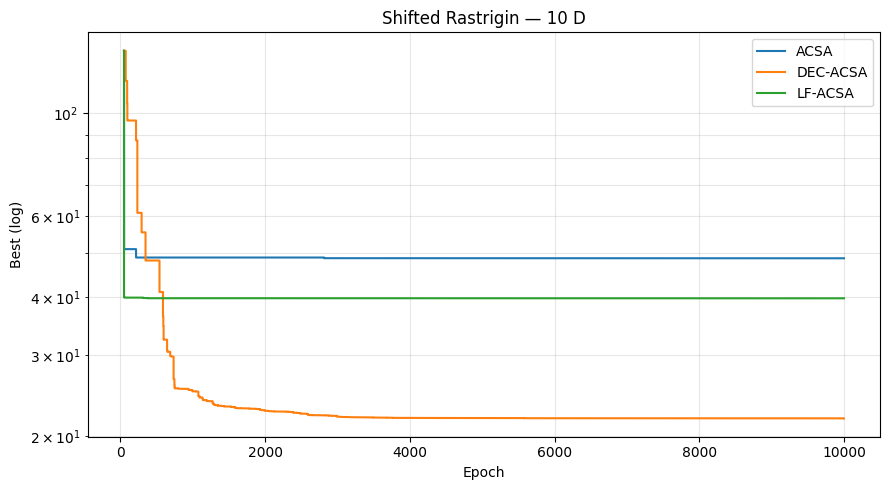

In [44]:
dimension = 10
population_size = 50
max_evaluations = 10000
seed = 42

lb = np.full(dimension, -5.12)
ub = np.full(dimension, 5.12)

algorithms = [
    ("ACSA", ACSA),
    ("DEC-ACSA", DECACSA),
    ("LF-ACSA", ACSA_Levy),
]

plt.figure(figsize=(9, 5))

print("Function: Shifted Rastrigin")
print(f"Optimum: {np.full(dimension, 2.0)}")
print("Minimum: 0\n")


for name, algorithm in algorithms:
    optimizer = algorithm(
        obj_func=shifted_rastrigin,
        lb=lb,
        ub=ub,
        pop_size=population_size,
        max_fes=max_evaluations,
        NH_rate=0.20,
        S=0.10,
        seed=seed,
    )

    solution, fitness, fes, curve, nfe = optimizer.optimize()

    print(f"{name:<12} {fitness:>16.8e} {nfe:>16d}")
    print("Best solution:", np.round(solution, 6))
    print()

    plt.step(
        fes,
        np.maximum(curve, 1e-12),
        where="post",
        label=name,
    )

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Best (log)")
plt.title(f"Shifted Rastrigin — {dimension} D")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()